##Project: Content Monetization Modeling

##Objective:
Predict YouTube ad revenue using engagement metrics such as views,
likes, comments, and engagement rate.

##Workflow:
1. Data Cleaning and EDA
2. Feature Engineering
3. Model Building
4. Model Evaluation
5. Streamlit App Deployment

##Data Cleaning

In [ ]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
#Loading the data

df_raw=pd.read_csv('/content/youtube_ad_revenue_dataset (1).csv')

In [ ]:
df_raw.shape

#(122400, 12)

(122400, 12)

In [ ]:
df_raw.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [ ]:
df_raw.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [ ]:
df_raw.describe(include='object')

,video_id,date,category,device,country
count,122400,122400,122400,122400,122400
unique,5000,365,6,4,6
top,vid_3033,2025-04-03 10:50:40.993199,Education,TV,CA
freq,47,382,20514,30646,20603


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


##Checking if any Data Inconsistent Formats in Ctaegorical Columns

In [ ]:
Cat= df_raw.select_dtypes(include='object')
Cat.columns

Index(['video_id', 'date', 'category', 'device', 'country'], dtype='object')

In [ ]:
Cat_data=Cat.drop(['video_id','date'],axis=1)
Cat_data.columns

Index(['category', 'device', 'country'], dtype='object')

In [ ]:
for col in Cat_data.columns:
  print(df_raw[col].value_counts())
  print(df_raw[col].unique())

category
Education        20514
Music            20475
Tech             20444
Entertainment    20411
Gaming           20359
Lifestyle        20197
Name: count, dtype: int64
['Entertainment' 'Gaming' 'Education' 'Music' 'Tech' 'Lifestyle']
device
TV         30646
Mobile     30598
Tablet     30579
Desktop    30577
Name: count, dtype: int64
['TV' 'Tablet' 'Mobile' 'Desktop']
country
CA    20603
DE    20582
IN    20564
AU    20313
UK    20269
US    20069
Name: count, dtype: int64
['IN' 'CA' 'UK' 'US' 'DE' 'AU']


##Checking for Duplicates

In [ ]:
df_raw.duplicated().sum()

np.int64(2400)

In [ ]:
df_raw.drop(columns=['video_id']).duplicated().sum()

np.int64(2400)

In [ ]:
#Dropping Duplicates

df_raw=df_raw.drop_duplicates()

In [ ]:
df_raw.duplicated().sum()

np.int64(0)

In [ ]:
df_raw.shape

(120000, 12)

##Handling Null Values

In [ ]:
df_raw.isna().sum()

,0
video_id,0
date,0
views,0
likes,6000
comments,6000
watch_time_minutes,6000
video_length_minutes,0
subscribers,0
category,0
device,0


##Imputing Null Values in 'likes' Column

In [ ]:
df_raw['likes'].value_counts()

,count
likes,
1507.0,87
1036.0,87
776.0,86
792.0,86
552.0,85
...,...
2036.0,1
2044.0,1
2048.0,1


In [ ]:
df_raw['likes'].describe()

,likes
count,114000.000000
mean,1099.585044
std,519.526733
min,195.000000
25%,650.000000
50%,1102.000000
75%,1547.250000
max,2061.000000


<Axes: ylabel='Frequency'>

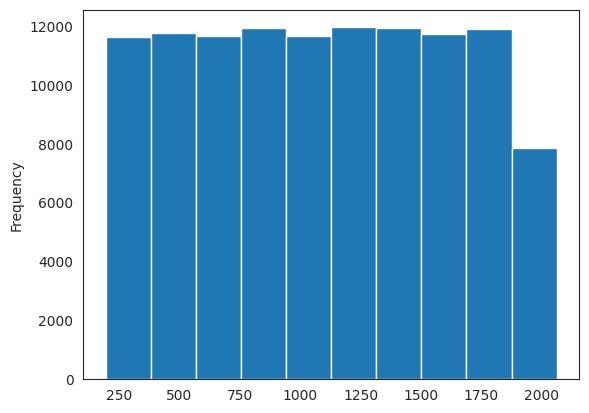

In [ ]:
df_raw['likes'].plot(kind='hist')

<Axes: >

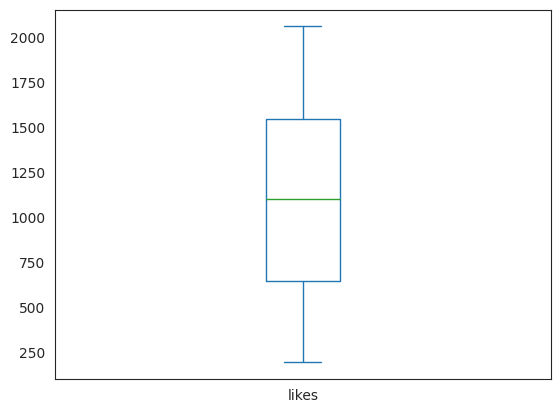

In [ ]:
df_raw['likes'].plot(kind='box')

In [ ]:
#Percentage of Null Values in 'likes'

df_raw['likes'].isna().mean()*100

np.float64(5.0)

In [ ]:
#Correlation between 'likes' and all other Numerical Columns

df_raw.corr(numeric_only=True)['likes'].sort_values(ascending=False)

,likes
likes,1.000000
engagement_rate,0.969901
ad_revenue_usd,0.146269
views,0.015607
subscribers,0.003622
watch_time_minutes,0.002864
video_length_minutes,0.001817
comments,-0.002138


In [ ]:
Cat.columns

Index(['video_id', 'date', 'category', 'device', 'country'], dtype='object')

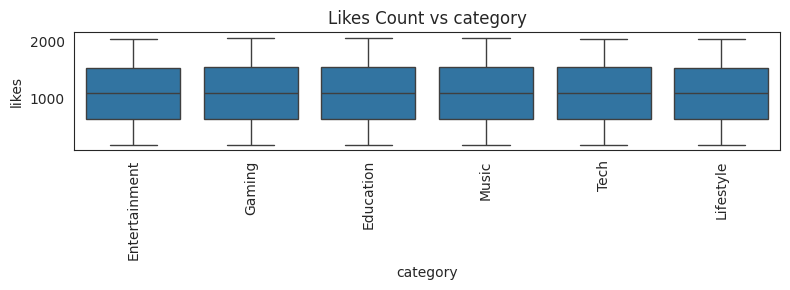

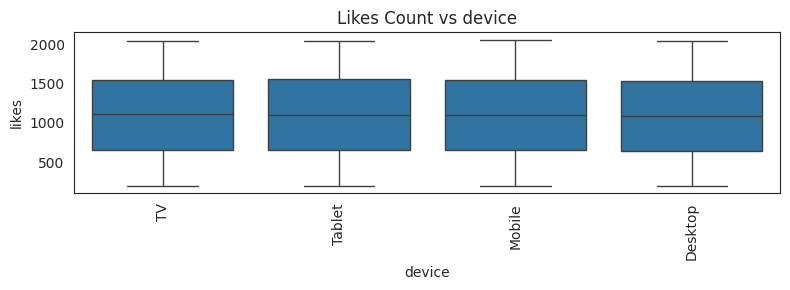

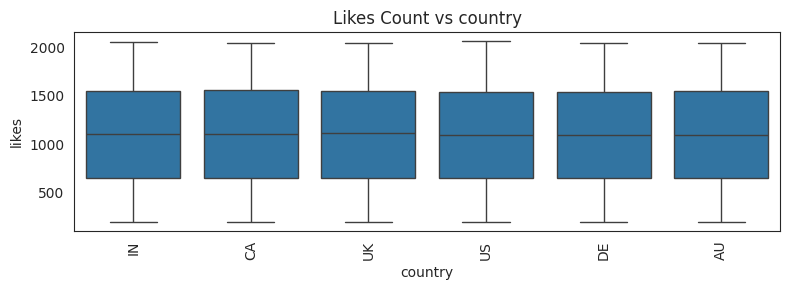

In [ ]:
#Box Plots for all the Categorical COlumns VS ['likes']

for col in Cat_data.columns:
        plt.figure(figsize=(8,3))
        sns.boxplot(x=col, y='likes', data=df_raw)
        plt.xticks(rotation=90)
        plt.title(f'Likes Count vs {col}')
        plt.tight_layout()
        plt.show()

In [ ]:
df_raw[df_raw['likes'].isna()]['views']

,views
9,10051
10,9907
41,9968
47,10001
82,9925
...,...
122321,10056
122329,10085
122358,10186
122361,10087


In [ ]:
#Therefore 'likes' showed no predictive relationship with other features
#So choosing median to impute its null values

print(df_raw['likes'].median())
#
print(df_raw['likes'].mean())

1102.0
1099.5850438596492


In [ ]:
df_raw['likes'].fillna(df_raw['likes'].median(),inplace=True)

In [ ]:
df_raw['likes'].isna().sum()

np.int64(0)

In [ ]:
df_raw.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate,now_column
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.155093,28438.189241
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.098632,237784.233126
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.214519,264547.797480
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.142814,118103.592229
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.236121,65621.958856


In [ ]:
df_raw['']

In [ ]:
df_raw['views'].min()

9521

##Imputing Null Values in 'comments'

In [ ]:
df_raw['comments'].describe()

,comments
count,114000.000000
mean,274.349842
std,129.746796
min,48.000000
25%,162.000000
50%,274.000000
75%,387.000000
max,515.000000


In [ ]:
df_raw['comments'].value_counts()

,count
comments,
323.0,294
158.0,293
236.0,291
252.0,289
190.0,289
...,...
48.0,4
511.0,3
512.0,3


In [ ]:
#Percentage of null values in 'comments'

df_raw['comments'].isna().mean()*100

np.float64(5.0)

<Axes: ylabel='Frequency'>

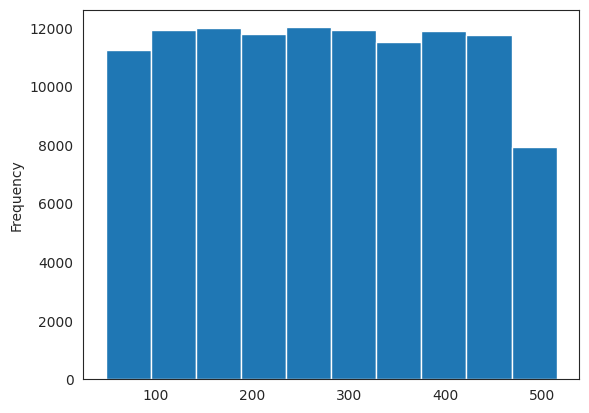

In [ ]:
df_raw['comments'].plot(kind='hist')

<Axes: >

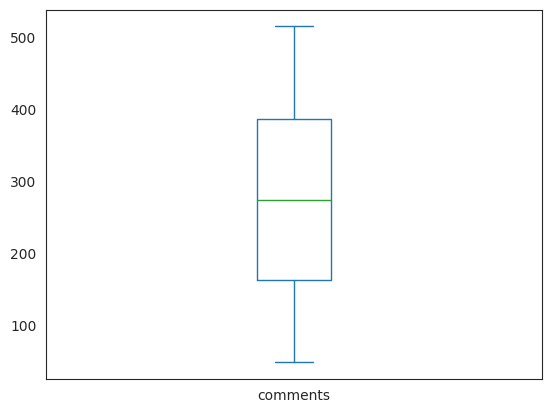

In [ ]:
df_raw['comments'].plot(kind='box')

In [ ]:
#Lets take correlation between 'Comments' and other Numerical Variables

df_raw.corr(numeric_only=True)['comments'].sort_values(ascending=False)

,comments
comments,1.000000
ad_revenue_usd,0.034494
views,0.018597
watch_time_minutes,-0.000749
subscribers,-0.001564
likes,-0.002080
video_length_minutes,-0.002233


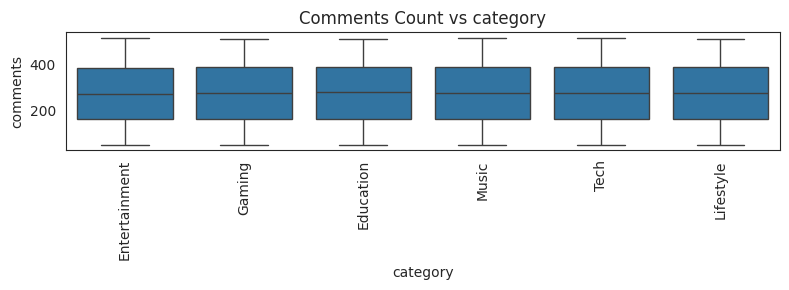

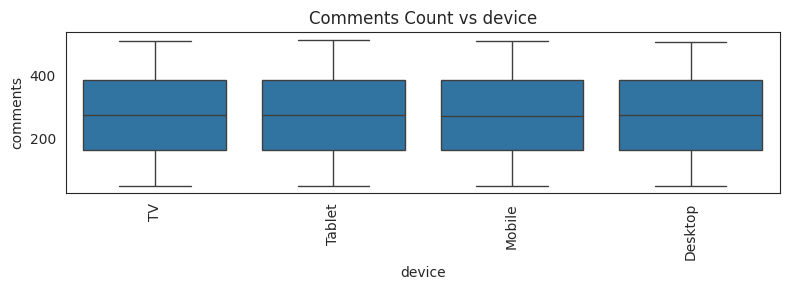

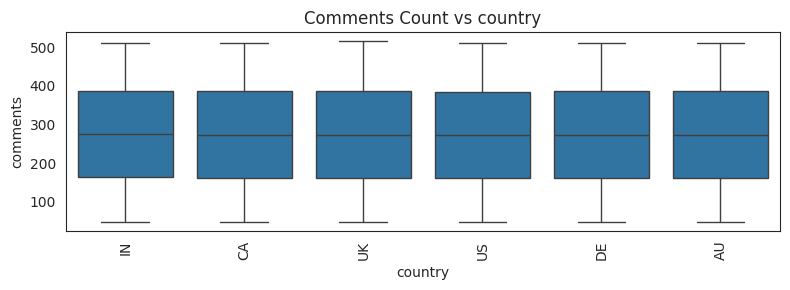

In [ ]:
#Lets check the Box plot of 'comments' Vs all other Cat columns

for col in Cat_data.columns:
        plt.figure(figsize=(8,3))
        sns.boxplot(x=col, y='comments', data=df_raw)
        plt.xticks(rotation=90)
        plt.title(f'Comments Count vs {col}')
        plt.tight_layout()
        plt.show()

In [ ]:
#Therefore 'comments' showed no predictive relationship with other features
#So choosing median to impute its null values

print(df_raw['comments'].median())
#
print(df_raw['comments'].mean())

274.0
274.3498421052632


In [ ]:
df_raw['comments'].fillna(df_raw['comments'].median(),inplace=True)

In [ ]:
df_raw['comments'].isna().sum()

np.int64(0)

##Imputing Null Values in watch_time_minutes

In [ ]:
df_raw['watch_time_minutes'].describe()

,watch_time_minutes
count,114000.000000
mean,37540.749921
std,12987.818758
min,14659.105562
25%,26364.159667
50%,37522.221205
75%,48782.739997
max,61557.670089


<Axes: ylabel='Frequency'>

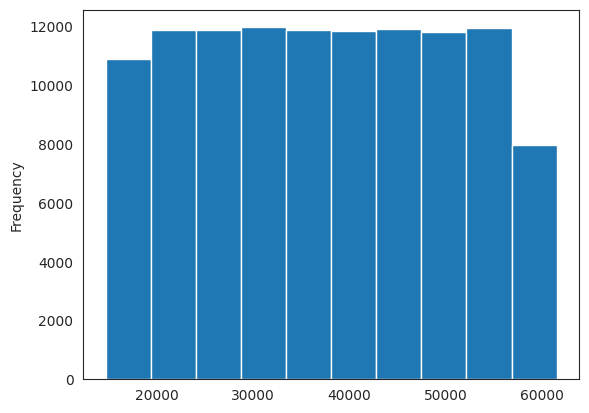

In [ ]:
df_raw['watch_time_minutes'].plot(kind='hist')

<Axes: >

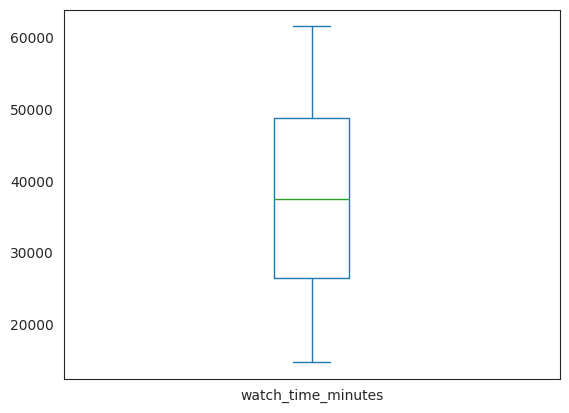

In [ ]:
df_raw['watch_time_minutes'].plot(kind='box')

In [ ]:
#Percentage of Null values in 'watch_time_minutes'

df_raw['watch_time_minutes'].isna().mean()*100

np.float64(5.0)

In [ ]:
#Lets take correlation between 'watch_time_minutes' and other Numerical Variables

df_raw.corr(numeric_only=True)['watch_time_minutes'].sort_values(ascending=False)

,watch_time_minutes
watch_time_minutes,1.000000
ad_revenue_usd,0.988869
views,0.026737
subscribers,0.004734
likes,0.002792
video_length_minutes,-0.000398
comments,-0.000732


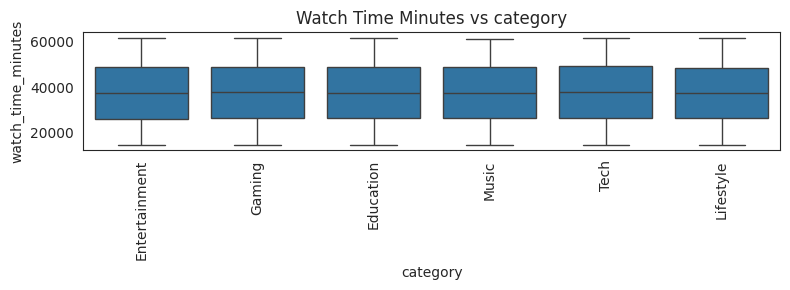

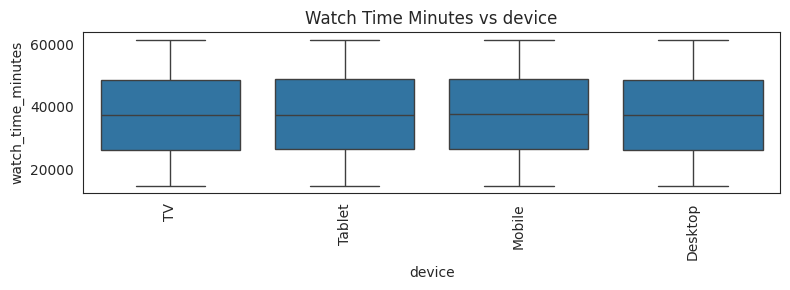

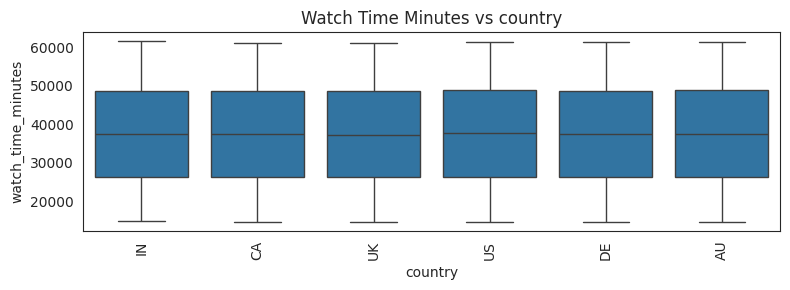

In [ ]:
#Lets check the Box plot of 'watch_time_minutes' Vs all other Cat columns

for col in Cat_data.columns:
        plt.figure(figsize=(8,3))
        sns.boxplot(x=col, y='watch_time_minutes', data=df_raw)
        plt.xticks(rotation=90)
        plt.title(f'Watch Time Minutes vs {col}')
        plt.tight_layout()
        plt.show()

In [ ]:
# 'watch_time_minutes' contains approximately 5% missing values.
# Although it shows strong correlation with the target variable (ad_revenue_usd),
# using the target variable for imputation would introduce data leakage.
# Since other features show weak correlation and missing values are low,
# median imputation is applied to preserve the distribution.

In [ ]:
print(df_raw['watch_time_minutes'].median())
#
print(df_raw['watch_time_minutes'].mean())

37522.22120523364
37540.74992097499


In [ ]:
df_raw['watch_time_minutes'].fillna(df_raw['watch_time_minutes'].median(),inplace=True)

In [ ]:
df_raw['watch_time_minutes'].isna().sum()

np.int64(0)

##Data Types Conversion
Ensuring all columns have appropriate data types for analysis

In [ ]:
df_raw.dtypes

,0
video_id,object
date,object
views,int64
likes,float64
comments,float64
watch_time_minutes,float64
video_length_minutes,float64
subscribers,int64
category,object
device,object


In [ ]:
df_raw.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [ ]:
#Changing ['date'] Datatype from 'object' to 'datetime'

df_raw['date']=pd.to_datetime(df_raw['date'],errors='coerce')

In [ ]:
#Changing ['likes','comments'] Data type from 'float64' to 'int64'

df_raw['likes']= df_raw['likes'].astype('int64')
df_raw['comments']=df_raw['comments'].astype('int64')

In [ ]:
df_raw.dtypes

,0
video_id,object
date,datetime64[ns]
views,int64
likes,int64
comments,int64
watch_time_minutes,float64
video_length_minutes,float64
subscribers,int64
category,object
device,object


##Feature Engineering

In [ ]:
df_raw['now_column']=df_raw['views']*df_raw['video_length_minutes']

In [ ]:
#Correlation
df_raw.corr(numeric_only=True)['watch_time_minutes'].sort_values(ascending=False)

,watch_time_minutes
watch_time_minutes,1.000000
ad_revenue_usd,0.988869
views,0.026737
subscribers,0.004734
engagement_rate,0.003129
likes,0.002864
now_column,0.000115
video_length_minutes,-0.000398
comments,-0.000749


In [ ]:
df_raw.corr(numeric_only=True)['watch_time_minutes'].sort_values(ascending=False)

In [ ]:
#'engagement_rate' derived column

df_raw['engagement_rate']=(df_raw['likes']+df_raw['comments'])/df_raw['views']
df_raw

In [ ]:
df_raw['engagement_rate']

,engagement_rate
0,0.155093
1,0.098632
2,0.214519
3,0.142814
4,0.236121
...,...
122395,0.184715
122396,0.174961
122397,NaN
122398,0.168164


In [ ]:
df_raw.isna().sum()

,0
video_id,0
date,0
views,0
likes,0
comments,0
watch_time_minutes,0
video_length_minutes,0
subscribers,0
category,0
device,0


In [ ]:
#Dropping unwanted columns for Model Building

df_raw=df_raw.drop(['video_id','date'],axis=1)

In [ ]:
df_raw.shape

(120000, 11)

In [ ]:
df_raw.columns

Index(['views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'engagement_rate'],
      dtype='object')

##Data Cleaning Summary

The original dataset contained 122,400 records.

*   2,400 duplicate rows were identified and removed.
*   The final cleaned dataset contains 120,000 unique records and 11 features.
*   Missing values were handled using median imputation.
*   A new feature engagement_rate was engineered to capture user interaction.

##Saving the Cleaned Dataset as a New CSV File

In [ ]:

df_raw.to_csv('youtube_df_cleaned.csv',index=False)

In [ ]:
df_cleaned=pd.read_csv('/content/youtube_df_cleaned.csv')

In [ ]:
df_cleaned.shape

(120000, 11)

In [ ]:
df_cleaned.isna().sum()

,0
views,0
likes,0
comments,0
watch_time_minutes,0
video_length_minutes,0
subscribers,0
category,0
device,0
country,0
ad_revenue_usd,0


In [ ]:
df_cleaned.duplicated().sum()

np.int64(0)

In [ ]:
df_cleaned.head()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate
0,9936,1221,320,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.155093
1,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.098632
2,10097,1979,187,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.214519
3,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.142814
4,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.236121


#Univariate

In [ ]:
df_cleaned.columns

Index(['views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'engagement_rate'],
      dtype='object')

In [ ]:
df_cleaned.dtypes

,0
views,int64
likes,int64
comments,int64
watch_time_minutes,float64
video_length_minutes,float64
subscribers,int64
category,object
device,object
country,object
ad_revenue_usd,float64


In [ ]:
Num_Cont=df_cleaned.select_dtypes(include=['int64','float64'])

In [ ]:
Num_Cont.columns

Index(['views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'ad_revenue_usd',
       'engagement_rate'],
      dtype='object')

In [ ]:
Num_Cont.shape

(120000, 8)

In [ ]:
Cat_clm = df_cleaned.select_dtypes(include='object')

In [ ]:
Cat_clm.columns

Index(['category', 'device', 'country'], dtype='object')

In [ ]:
Cat_clm.shape

(120000, 3)

##Histogram for all the Num_Cont Variables

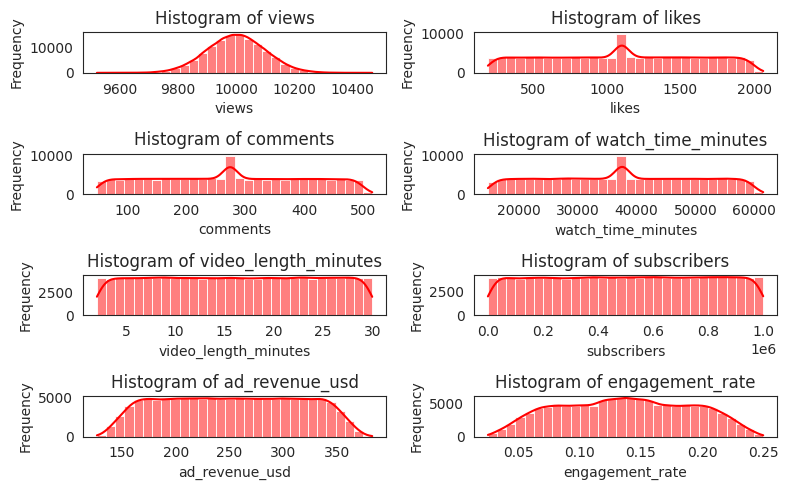

In [ ]:
cols = Num_Cont.columns

fig, axes = plt.subplots(4, 2, figsize=(8, 5))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_cleaned[col], bins=30, kde=True, ax=axes[i], color='#FF0000')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

##Boxplots for all the Num_Cont Columns to detect Outliers

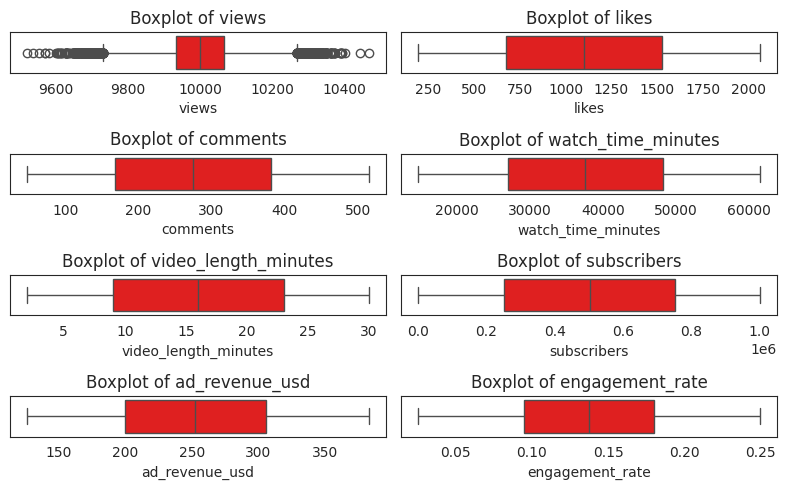

In [ ]:

sns.set_style("white")

fig, axes = plt.subplots(4, 2, figsize=(8, 5))
axes = axes.flatten()

for i, col in enumerate(cols):

    sns.boxplot(
        x=df_cleaned[col],
        ax=axes[i],
        color="#FF0000",
        linewidth=1
    )

    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

##Outlier Analysis

Boxplots were used to detect potential outliers in numerical variables.
Most features showed a stable distribution without extreme values.
However, the views variable exhibited some outliers, which is expected in YouTube datasets due to the presence of viral or unusually low-performing videos.

Since these values represent legitimate observations rather than data errors, they were retained in the dataset.

##Pie Charts for all the Categorical Columns as it have only minimal number of categories

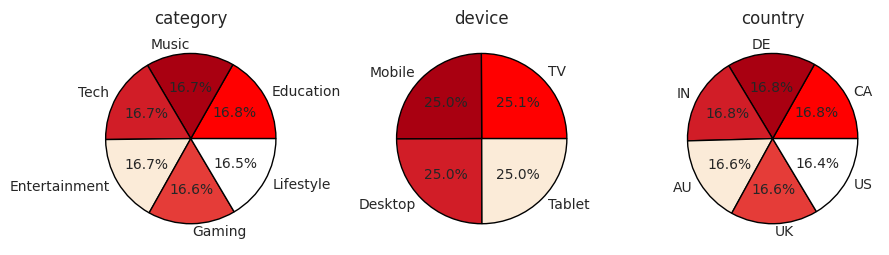

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(9,3))
youtube_colors=["#FF0000","#A90011","#D11D27","#FBEBD8","#E53C38","white"]
#youtube_colors=["#","#CC0000","#E62117","#C4302B","#990000","#B22222"]


for i, col in enumerate(Cat_clm):

    df_cleaned[col].value_counts().plot.pie(
        autopct='%1.1f%%',
        ax=axes[i],
        colors=youtube_colors,
        wedgeprops={'edgecolor':'black'}
    )

    axes[i].set_title(f'{col}')
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

##Bivariate Analysis

##Scatterplots to visualize the relationship between Revenue-Numerical Variable(Target Column) and all other Num_Cont Columns

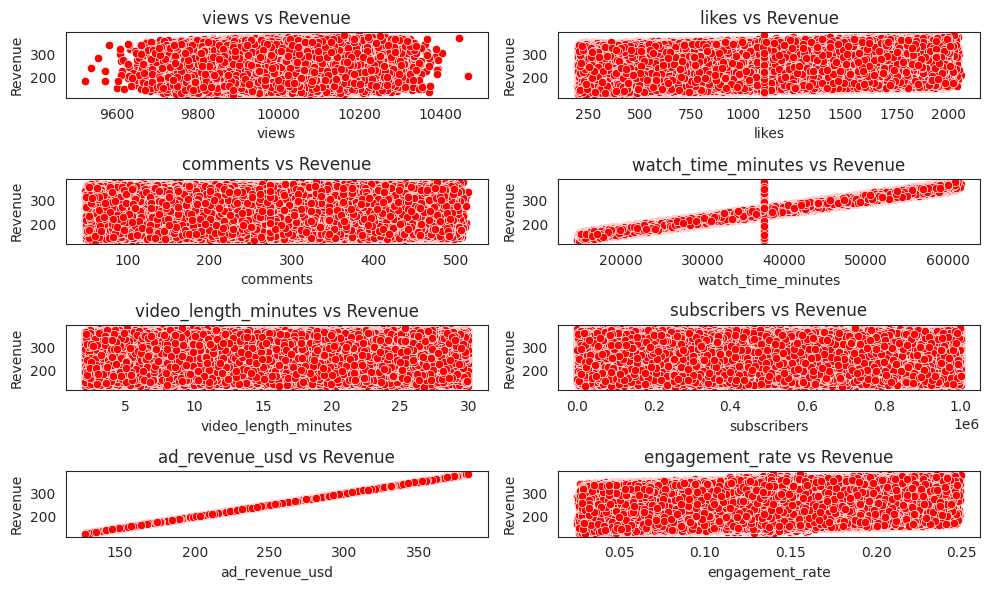

In [ ]:
fig, axes = plt.subplots(4,2, figsize=(10,6))
axes = axes.flatten()

for i, col in enumerate(Num_Cont):

    sns.scatterplot(
        x=df_cleaned[col],
        y=df_cleaned['ad_revenue_usd'],
        color="#FF0000",
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs Revenue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

##Box Plots to visualize Revenue Vs All other Categorical Variables

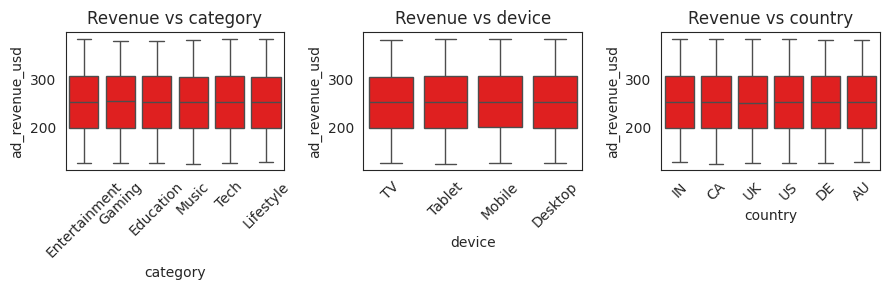

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(9,3))

for i, col in enumerate(Cat_clm):

    sns.boxplot(
        x=df_cleaned[col],
        y=df_cleaned['ad_revenue_usd'],
        ax=axes[i],
        color="#FF0000"
    )

    axes[i].set_title(f'Revenue vs {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##Correlation Heatmap

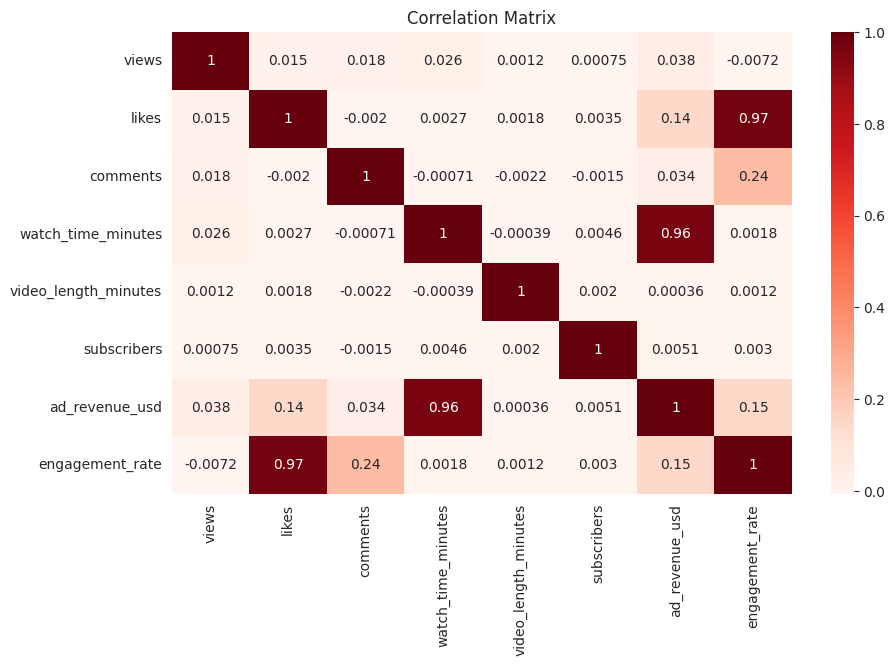

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_cleaned.corr(numeric_only=True),
    annot=True,
    cmap="Reds"
)

plt.title("Correlation Matrix")
plt.show()